# 支持向量机

https://www.runoob.com/ml/ml-svm.html


## 支持向量机 

支持向量机（Support Vector Machine，简称 SVM）是一种监督学习算法，主要用于分类和回归问题。

SVM 的核心思想是找到一个最优的超平面，将不同类别的数据分开。这个超平面不仅要能够正确分类数据，还要使得两个类别之间的间隔（margin）最大化。

超平面：

- 在二维空间中，超平面是一个直线。
- 在三维空间中，超平面是一个平面。
- 在更高维空间中，超平面是一个分割空间的超平面。

支持向量：
- 支持向量是离超平面最近的样本点。这些支持向量对于定义超平面至关重要。
- 支持向量机通过最大化支持向量到超平面的距离（即最大化间隔）来选择最佳的超平面。

最大间隔：
- SVM的目标是最大化分类间隔，使得分类边界尽可能远离两类数据点。这可以有效地减少模型的泛化误差。

核技巧（Kernel Trick）：

- 对于非线性可分的数据，SVM使用核函数将数据映射到更高维的空间，在这个空间中，数据可能是线性可分的。
- 常用的核函数有：线性核、多项式核、径向基函数（RBF）核等。

SVM 分类流程
1. 选择一个超平面：找到一个能够最大化分类边界的超平面。
2. 训练支持向量：通过支持向量机算法，选择离超平面最近的样本点作为支持向量。
3. 通过最大化间隔来找到最优超平面：选择一个最优超平面，使得间隔最大化。
4. 使用核函数处理非线性问题：通过核函数将数据映射到高维空间来解决非线性可分问题。

## 使用 Python 实现 SVM

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = iris.target

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
# 创建SVM分类器
clf = svm.SVC(kernel='linear')  # 使用线性核函数

# 训练模型
clf.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [5]:
# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

模型准确率: 0.80


模型准确率: 0.80


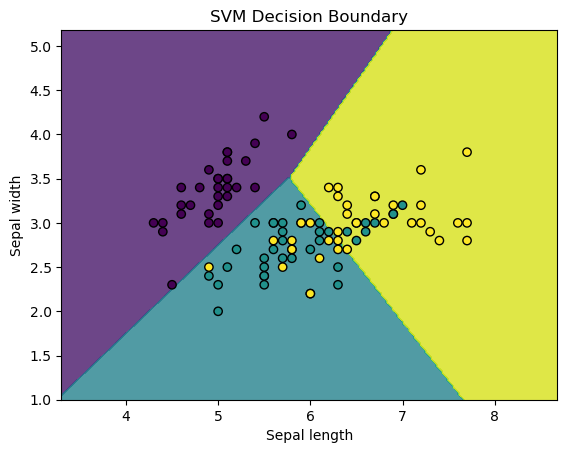

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = iris.target

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建SVM分类器
clf = svm.SVC(kernel='linear')  # 使用线性核函数

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

# 绘制决策边界
def plot_decision_boundary(X, y, model):
    h = .02  # 网格步长
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('SVM Decision Boundary')
    plt.show()

plot_decision_boundary(X_train, y_train, clf)